In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
df = pd.read_csv("data/raw/ratings.csv")


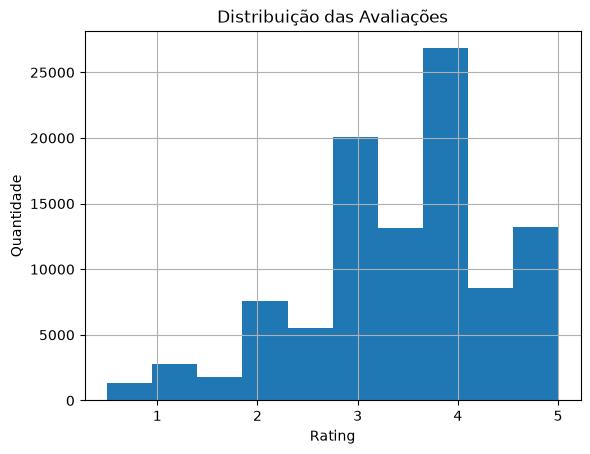

In [4]:
df["rating"].hist(bins=10)

plt.title("Distribuição das Avaliações")
plt.xlabel("Rating")
plt.ylabel("Quantidade")

plt.show()

In [5]:
top_movies = (
    df.groupby("movieId")
      .rating.mean()
      .sort_values(ascending=False)
)

print(top_movies.head(10))

movieId
187717    5.0
6983      5.0
5328      5.0
95843     5.0
3941      5.0
3940      5.0
3939      5.0
7815      5.0
162414    5.0
162344    5.0
Name: rating, dtype: float64


In [6]:
movie_stats = (
    df.groupby("movieId")
      .agg(
          avg_rating=("rating", "mean"),
          total_ratings=("rating", "count")
      )
)

In [7]:
movie_stats = movie_stats[
    movie_stats["total_ratings"] >= 100
]

In [8]:
top_movies = (
    movie_stats
    .sort_values("avg_rating", ascending=False)
)

In [9]:
print(top_movies.head(10))

         avg_rating  total_ratings
movieId                           
318        4.429022            317
858        4.289062            192
2959       4.272936            218
1221       4.259690            129
48516      4.252336            107
1213       4.250000            126
912        4.240000            100
58559      4.238255            149
50         4.237745            204
1197       4.232394            142


In [10]:
movies = pd.read_csv("data/raw/movies.csv")

resultado = (
    top_movies
    .merge(
        movies,
        on="movieId"
    )
)

In [11]:
print(df["userId"].nunique())
print(df["movieId"].nunique())
print(df["rating"].mean())

610
9724
3.501556983616962


In [13]:
display(resultado)

,movieId,avg_rating,total_ratings,title,genres
0,318,4.429022,317,"Shawshank Redemption, The (1994)",Crime|Drama
1,858,4.289062,192,"Godfather, The (1972)",Crime|Drama
2,2959,4.272936,218,Fight Club (1999),Action|Crime|Drama|Thriller
3,1221,4.259690,129,"Godfather: Part II, The (1974)",Crime|Drama
4,48516,4.252336,107,"Departed, The (2006)",Crime|Drama|Thriller
...,...,...,...,...,...
133,185,3.040179,112,"Net, The (1995)",Action|Crime|Thriller
134,434,3.034653,101,Cliffhanger (1993),Action|Adventure|Thriller
135,586,2.995690,116,Home Alone (1990),Children|Comedy
136,153,2.916058,137,Batman Forever (1995),Action|Adventure|Comedy|Crime
